# Baseline Model


In [10]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.data import load_data, split_features_target
from src.model import BASELINE_PARAMS
from src.objective import cv_auc, CVConfig

PROJECT_ROOT = Path.cwd().parent
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_style("whitegrid")

In [11]:
data_path = PROJECT_ROOT / "data" / "processed" / "train.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path}")

df = load_data(path=data_path)
X, y = split_features_target(df)

baseline_auc, baseline_std = cv_auc(
    X,
    y,
    BASELINE_PARAMS,
    CVConfig(),
)

print(
    f"Baseline cross-validation ROC-AUC: "
    f"{baseline_auc:.4f} ± {baseline_std:.4f}"
)

Baseline cross-validation ROC-AUC: 0.8743 ± 0.0032


In [12]:
baseline_results = pd.DataFrame({
    "model": ["Baseline"],
    "mean_roc_auc": [baseline_auc],
    "std_roc_auc": [baseline_std],
})

baseline_results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False,
)

baseline_results

,model,mean_roc_auc,std_roc_auc
0,Baseline,0.874293,0.003167


In [13]:
import json

with open(RESULTS_DIR / "baseline_hyperparameters.json", "w") as file:
    json.dump(BASELINE_PARAMS, file, indent=4, default=str)

print("Baseline results and hyperparameters saved successfully.")

Baseline results and hyperparameters saved successfully.


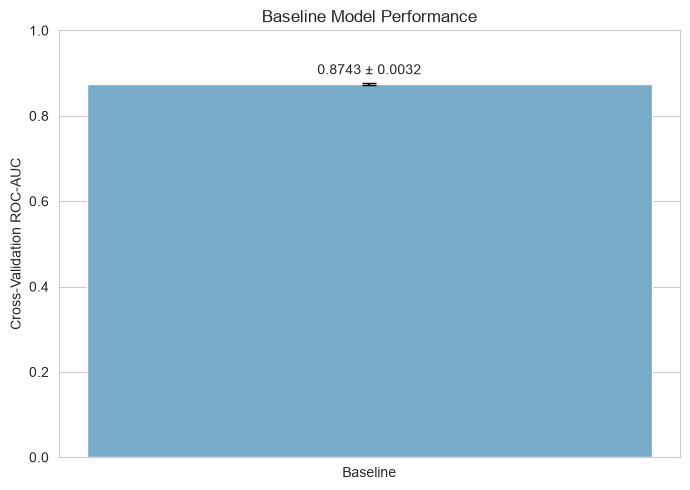

In [14]:
# Plot of the baseline ROC-AUC performance
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=baseline_results,
    x="model",
    y="mean_roc_auc",
    color="#6BAED6",
)

ax.errorbar(
    x=[0],
    y=[baseline_auc],
    yerr=[baseline_std],
    fmt="none",
    color="black",
    capsize=5,
    linewidth=1.5,
)

ax.set_title("Baseline Model Performance")
ax.set_xlabel("")
ax.set_ylabel("Cross-Validation ROC-AUC")
ax.set_ylim(0, 1)

ax.text(
    0,
    baseline_auc + baseline_std + 0.02,
    f"{baseline_auc:.4f} ± {baseline_std:.4f}",
    ha="center",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "baseline_performance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Baseline Model Results

The baseline LightGBM model achieved a mean cross-validation ROC-AUC of **0.8743**, with a standard deviation of **0.0032** across the validation folds.

The low standard deviation indicates that the model's performance was relatively consistent across folds. This baseline score will be used to compare the performance of the random-search and Bayesian-optimization models.

The results are saved to:

- `results/baseline_results.csv`
- `results/baseline_hyperparameters.json`

The performance figure is saved to:

- `figures/baseline_performance.png`